# 아래는 LMS 의 코드를 따라 실행해본 결과이다

In [45]:
# 라이브러리 인스톨!
!pip install cmake
!pip install opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [46]:
# os        : 파일 경로
# cv2       : 이미지 읽기/회전/전처리/합성
# matplotlib: 결과 이미지를 노트북에 출력
# numpy     : 좌표 계산, 배열 연산
# dlib      : 얼굴 검출기 

import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dlib

print("ready")


ready


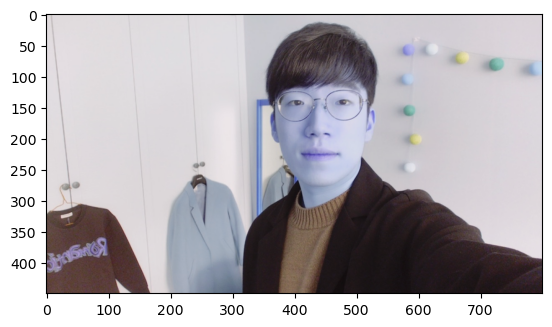

In [47]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
img_show = img_bgr.copy()      # 출력용 이미지를 따로 보관합니다
plt.imshow(img_bgr) # 이미지를 출력하기 위해 출력할 이미지를 올려준다. (실제 출력은 하지 않음)
plt.show() # 이미지를 출력해준다. (실제 출력)

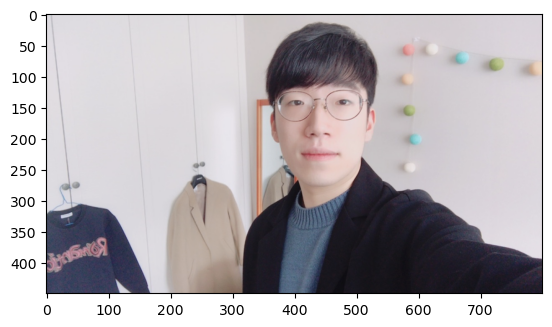

In [48]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [49]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [50]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


rectangles[[(345, 98) (531, 284)]]


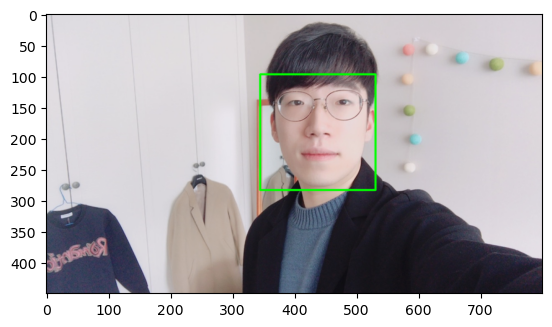

In [51]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [52]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-06-22 06:09:10--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-06-22 06:09:11--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  8.96MB/s    in 8.3s    

2026-06-22 06:09:20 (7.34 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [53]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [54]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


In [55]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(345, 98) (531, 284)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2 # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(437, 182)
(x,y) : (437,89)
(w,h) : (187,187)


In [56]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png') # 왕관 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 왕관 이미지의 차원 확인

(187, 187, 3)


In [57]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 437
# y는 이미지에서 코 부위의 y값 = 89
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
refined_x = x - w // 2 # 437 - (187//2) = 437-93 = 344
refined_y = y - h # 89-187 = -98
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.
# 즉, refined_x, refined_y값에서 왕관 이미지가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') # 음수 발생 : 이미지 범위를 벗어남
# 우리는 현재 이마 자리에 왕관을 두고 싶은건데, 이마위치 - 왕관 높이를 했더니 이미지의 범위를 초과하여 음수가 나오는 것
# opencv는 ndarray데이터를 사용하는데, ndarray는 음수인덱스에 접근 불가하므로 스티커 이미지를 잘라 줘야 한다.

(x,y) : (344,-98)


In [58]:
# 왕관 이미지가 이미지 밖에서 시작하지 않도록 조정이 필요함
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# 현재 상황에서는 -y 크기만큼 스티커를 crop 하고, top 의 x좌표와 y 좌표를 각각의 경우에 맞춰 원본 이미지의 경계 값으로 수정하면 아래와 같은 형식으로 나옵니다.
# 음수값 만큼 왕관 이미지(혹은 추후 적용할 스티커 이미지)를 자른다.
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
# 왕관 이미지를 씌우기 위해 왕관 이미지가 시작할 y좌표 값 조정
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0

print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (344,0)


In [59]:
# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지 입니다.
# 예제에서는 (344,0) 부터 (344+187, 0+89) 범위의 이미지를 의미합니다.
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_show[0:0+89, 344:344+187]
# img_show[0:89, 344:531]
# 즉, x좌표는 344~531 / y좌표는 0~89가 됨
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 왕관 이미지에서 사용할 부분은 0이 아닌 색이 있는 부분을 사용합니다.
# 왕관 이미지에서 0이 나오는 부분은 흰색이라는 뜻, 즉 이미지가 없다는 소리임.
# 현재 왕관 이미지에서는 왕관과 받침대 밑의 ------ 부분이 됨
# 그렇기 때문에 0인 부분(이미지가 없는 부분)은 제외하고 적용
# sticker_area는 원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지입니다.
# 즉, 왕관 이미지에서 왕관 이미지가 없는 부분(왕관과 받침대 밑의 ------ 부분)은 원본 이미지에서 미리 잘라놓은 sticker_area(스티커 적용할 부분 만큼 원본 이미지에서 자른 이미지)를 적용하고,
# 나머지 부분은 스티커로 채워주면 됨
# np.where는 조건에 해당하는 인덱스만 찾아서 값을 적용하는 방법이다.
# 아래 코드에서는 img_sticker가 0일 경우(왕관 이미지에서 왕관 부분 제외한 나머지 이미지)에는 sticker_area(원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지)를 적용하고,
# 나머지 부분은 img_sticker(왕관 이미지)를 적용한다.
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
print("슝~")

슝~


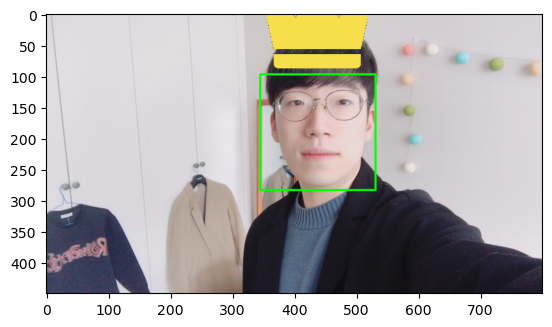

In [60]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

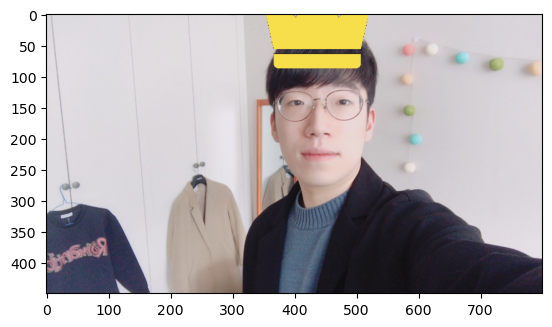

In [61]:
# 위에서 설명했으므로 생략
# 왕관 이미지
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_bgr은 7-2에서 rgb로만 적용해놓은 원본 이미지이다.
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) # rgb만 적용해놓은 원본 이미지에 왕관 이미지를 덮어 씌운 이미지가 나오게 된다.
plt.show()

# 여기서부터 아래는 고양이 수염을 붙인다

In [62]:
# image_dir  : 사람 사진과 cat.png가 들어있는 폴더
# model_path : 얼굴 랜드마크 모델 파일 경로

home_dir = os.getenv('HOME')
image_dir = os.path.join(home_dir, 'work/camera_sticker/images')
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')

# 처리할 이미지 목록
image_files = [
    'image.png',    # 기본 정면 사진
    'image1.png',   # 회전된 사진
    'image2.png',   # 회전된 사진
    'image3.png',   # 회전된 사진
    'image4.png',   # 멀리 찍은 사진
    'image5.png',   # 밝은 사진
]

# 고양이 수염 스티커 파일
sticker_file = 'cat.png'
sticker_path = os.path.join(image_dir, sticker_file)

print('image_dir:', image_dir)
print('sticker_path:', sticker_path)


image_dir: /home/jovyan/work/camera_sticker/images
sticker_path: /home/jovyan/work/camera_sticker/images/cat.png


In [63]:
#   이미지에서 얼굴 사각형을 찾는 역할
detector_hog = dlib.get_frontal_face_detector()

#   68개의 얼굴 포인트를 찾아주는 역할
landmark_predictor = dlib.shape_predictor(model_path)

print('detector ready')


detector ready


In [64]:
# 이미지 사진을 돌려가면서 정방향이 되는지 찾음
def rotate_image(img, rot):
   
    if rot == 0:
        return img.copy()
    if rot == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    if rot == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    if rot == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    raise ValueError(rot)

# 얼굴 검출할 때 돌렸던 이미지 다시 원위치로 돌림
def inverse_rotation(rot):
   
    return (360 - rot) % 360

# 고양이 수염 이미지 투명 배경으로 만들어줌
def make_cat_sticker_rgba(path, threshold=180, padding=8):

    src = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if src is None:
        raise FileNotFoundError(path)

    # 입력 이미지가 흑백/3채널/4채널 중 무엇이든 BGR 3채널로 통일
    if src.ndim == 2:
        bgr = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)
    elif src.shape[2] == 4:
        bgr = src[:, :, :3]
    else:
        bgr = src

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    # threshold보다 어두운 픽셀만 스티커로 사용함
    alpha = np.where(gray < threshold, 255, 0).astype(np.uint8)

    # 작은 점 노이즈 제거
    kernel = np.ones((3, 3), np.uint8)
    alpha = cv2.morphologyEx(alpha, cv2.MORPH_OPEN, kernel)

    # alpha가 있는 영역만 찾아서 crop
    ys, xs = np.where(alpha > 0)
    if len(xs) == 0:
        raise ValueError('스티커에서 검은 픽셀을 찾지 못했다. threshold 값을 조정해봐.')

    x1 = max(xs.min() - padding, 0)
    x2 = min(xs.max() + padding + 1, bgr.shape[1])
    y1 = max(ys.min() - padding, 0)
    y2 = min(ys.max() + padding + 1, bgr.shape[0])

    bgr = bgr[y1:y2, x1:x2]
    alpha = alpha[y1:y2, x1:x2]

    # 스티커 색상은 검정으로 고정
    black = np.zeros_like(bgr)
    rgba = cv2.merge([black[:, :, 0], black[:, :, 1], black[:, :, 2], alpha])
    return rgba

# 얼굴 검출 전 이미지 보정
# 이미지 너무 작으면 확대하고 밝기가 강하면 윤곽을 살린다
# 보정 후 다시 원위치
def preprocess_for_face_detection(img_bgr, scale=1.0):
    work = img_bgr.copy()

    # 작은 얼굴 대응: 이미지를 키워서 detector가 얼굴을 더 쉽게 찾기
    if scale != 1.0:
        work = cv2.resize(
            work,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC
        )

    # 흑백 이미지
    # 왜? 더 안정적으로 찾으니까~!
    gray = cv2.cvtColor(work, cv2.COLOR_BGR2GRAY)

    # 밝은 사진은 CLAHE로 얼굴 윤곽 살리기
    clahe = cv2.createCLAHE(
        clipLimit=2.5,
        tileGridSize=(8, 8)
    )
    gray = clahe.apply(gray)

    return gray, work

# 얼굴과 랜드마크 찾기
def find_face_and_landmarks_any_rotation(img_bgr):
    best = None

    rotations = [0, 90, 180, 270]
    scales = [1.0, 1.5, 2.0, 3.0]

    for rot in rotations:
        rotated_bgr = rotate_image(img_bgr, rot)

        for scale in scales:
            detect_img, scaled_bgr = preprocess_for_face_detection(
                rotated_bgr,
                scale=scale
            )

            # 이미지 확대해서 보기
            rects = detector_hog(detect_img, 2)

            if len(rects) == 0:
                continue

            # 얼굴이 여러 개 잡히면 가장 큰 얼굴을 사용
            rect = max(
                rects,
                key=lambda r: r.width() * r.height()
            )

            score = rect.width() * rect.height()

            # landmark predictor는 검출된 얼굴 사각형 안에서 포인트 찾기
            scaled_rgb = cv2.cvtColor(
                scaled_bgr,
                cv2.COLOR_BGR2RGB
            )

            points = landmark_predictor(
                scaled_rgb,
                rect
            )

            landmarks_scaled = np.array(
                [(p.x, p.y) for p in points.parts()],
                dtype=np.float32
            )

            # scale을 적용한 이미지에서 찾은 좌표이므로 원래 회전 이미지 좌표로 복원
            landmarks = landmarks_scaled / scale
            landmarks = landmarks.astype(np.int32)

            # 가장 큰 얼굴 후보를 best로 보관
            if best is None or score > best[0]:
                best = (
                    score,
                    rotated_bgr,
                    landmarks,
                    rot,
                    scale
                )

    if best is None:
        return None, None, None

    score, upright_bgr, landmarks, used_rot, used_scale = best

    return upright_bgr, landmarks, used_rot

# 고양이 수염을 얼굴에 맞게 회전
def rotate_rgba_keep_alpha(rgba, angle):

    h, w = rgba.shape[:2]
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)

    M[0, 2] += new_w / 2 - center[0]
    M[1, 2] += new_h / 2 - center[1]

    rotated = cv2.warpAffine(
        rgba,
        M,
        (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0)
    )
    return rotated

# 스티커 처리
def overlay_rgba(base_bgr, sticker_rgba, center_x, center_y):

    h, w = sticker_rgba.shape[:2]
    x1 = int(center_x - w // 2)
    y1 = int(center_y - h // 2)
    x2 = x1 + w
    y2 = y1 + h

    # 스티커가 이미지 밖으로 나가도 에러가 나지 않도록 경계 자르기
    bx1 = max(x1, 0)
    by1 = max(y1, 0)
    bx2 = min(x2, base_bgr.shape[1])
    by2 = min(y2, base_bgr.shape[0])

    if bx1 >= bx2 or by1 >= by2:
        return base_bgr

    sx1 = bx1 - x1
    sy1 = by1 - y1
    sx2 = sx1 + (bx2 - bx1)
    sy2 = sy1 + (by2 - by1)

    sticker_crop = sticker_rgba[sy1:sy2, sx1:sx2]
    alpha = sticker_crop[:, :, 3].astype(np.float32) / 255.0
    alpha = alpha[:, :, None]

    roi = base_bgr[by1:by2, bx1:bx2].astype(np.float32)
    sticker_rgb = sticker_crop[:, :, :3].astype(np.float32)

    blended = roi * (1 - alpha) + sticker_rgb * alpha
    base_bgr[by1:by2, bx1:bx2] = blended.astype(np.uint8)
    return base_bgr

# 얼굴에 고양이 수염 붙이기
def add_cat_whisker_to_upright_face(img_bgr, landmarks, sticker_rgba, size_ratio=0.70, nose_down_ratio=0.02):
  
    result = img_bgr.copy()

    # 고양이 수염 중심 위치: landmark 33번, 콧망울 아래 중심에 가까운 점
    nose_x = int(landmarks[33, 0])
    nose_y = int(landmarks[33, 1])

    # 얼굴 폭: 턱선 양끝 0번과 16번 사이 거리
    face_width = int(abs(landmarks[16, 0] - landmarks[0, 0]))
    if face_width <= 0:
        face_width = int(np.linalg.norm(landmarks[16] - landmarks[0]))

    # 얼굴 폭에 비례해서 수염 크기를 결정
    whisker_w = max(20, int(face_width * size_ratio))
    whisker_h = int(sticker_rgba.shape[0] * whisker_w / sticker_rgba.shape[1])

    sticker = cv2.resize(sticker_rgba, (whisker_w, whisker_h), interpolation=cv2.INTER_AREA)

    # 양쪽 눈 바깥쪽 점으로 얼굴 기울기를 계산
    left_eye = landmarks[36]
    right_eye = landmarks[45]
    angle = np.degrees(np.arctan2(right_eye[1] - left_eye[1], right_eye[0] - left_eye[0]))

    # 얼굴 기울기와 같은 각도로 수염도 회전
    sticker = rotate_rgba_keep_alpha(sticker, angle)

    # 33번 포인트에서 살짝 아래로 이동해 콧망울 끝에 더 가깝게 붙인다
    center_x = nose_x
    center_y = nose_y + int(face_width * nose_down_ratio)

    result = overlay_rgba(result, sticker, center_x, center_y)
    return result


(np.float64(-0.5), np.float64(511.5), np.float64(133.5), np.float64(-0.5))

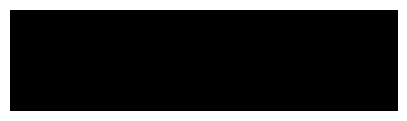

In [67]:
# 고양이 수염 준비
cat_sticker = make_cat_sticker_rgba(sticker_path, threshold=180, padding=8)

plt.figure(figsize=(5, 2))
plt.imshow(cv2.cvtColor(cat_sticker[:, :, :3], cv2.COLOR_BGR2RGB))
plt.axis('off')

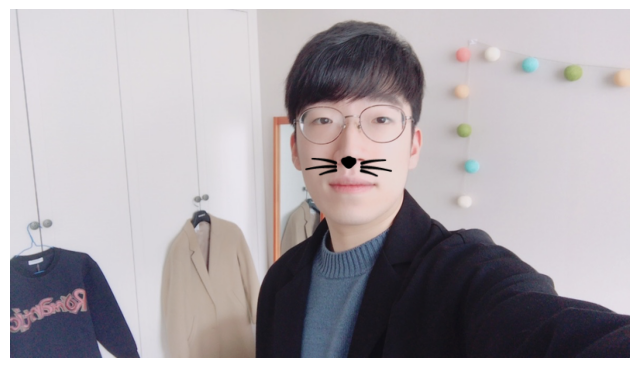

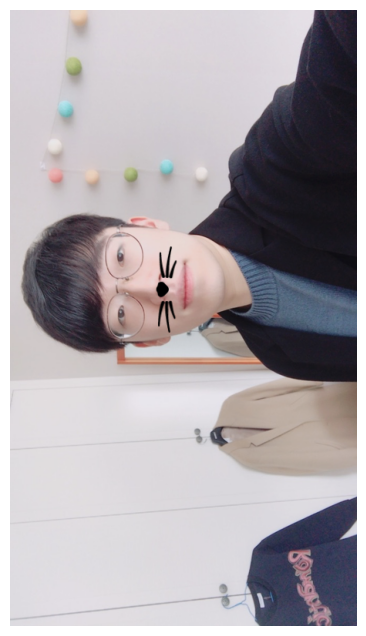

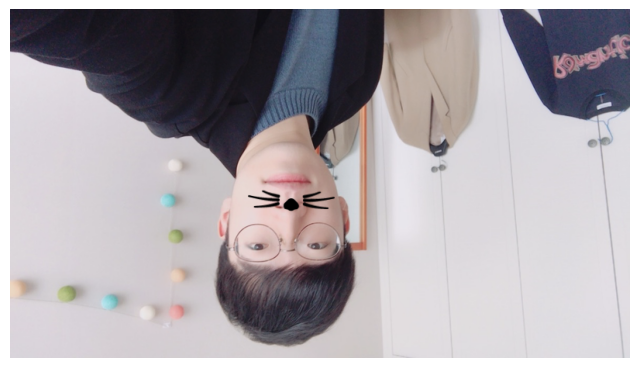

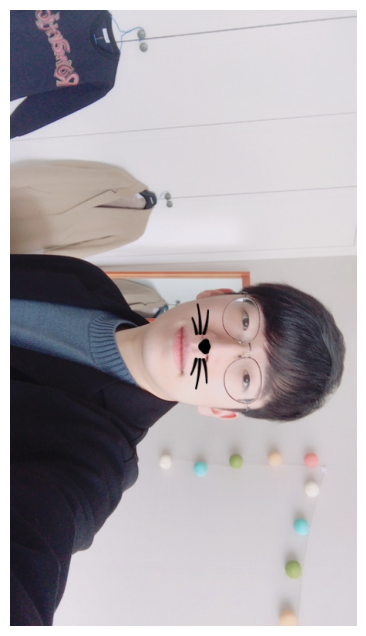

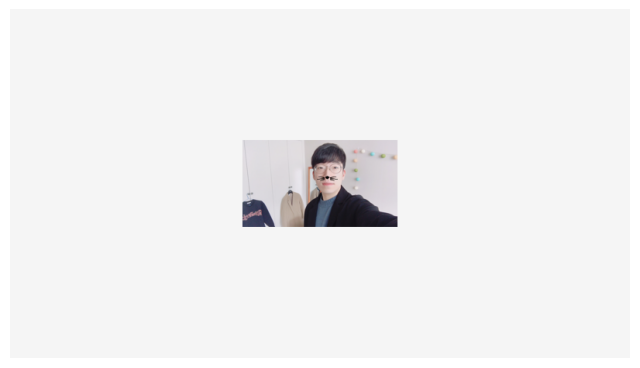

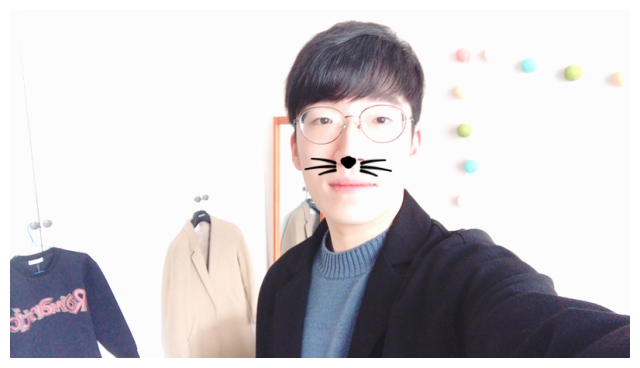

In [68]:
results = {}

for file_name in image_files:
    path = os.path.join(image_dir, file_name)
    img_bgr = cv2.imread(path)

    # 1) 회전/작은 얼굴/밝은 얼굴에 대응해서 얼굴과 랜드마크를 찾기
    upright_bgr, landmarks, used_rot = find_face_and_landmarks_any_rotation(img_bgr)

    # 2) 정방향 이미지 기준으로 수염을 붙이기
    upright_result = add_cat_whisker_to_upright_face(
        upright_bgr,
        landmarks,
        cat_sticker,
        size_ratio=0.70,       # 얼굴 폭 대비 수염 크기
        nose_down_ratio=0.01   # landmark 33번에서 얼굴 폭의 1%만큼 아래로 내림
    )

    # 3) 얼굴 검출을 위해 돌렸던 이미지를 원래 방향으로 되돌리기
    final_result = rotate_image(upright_result, inverse_rotation(used_rot))
    results[file_name] = final_result


    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


# 코드 설명 정리

dlib 68개 얼굴 랜드마크 중 33번 포인트를 기준으로 고양이 수염을 붙였습니다

30번: 코 끝 위쪽
31~35번: 콧망울 라인
33번: 콧망울 아래 중심에 가까운 점
그래서 수염 중심 좌표는 아래 코드로 정합니다.

nose_x = int(landmarks[33, 0])
nose_y = int(landmarks[33, 1])

그 다음 만큼 아래로 조금 내려서 콧망울 끝 쪽에 더 자연스럽게 붙입니다.nose_down_ratio=0.01 (1% 아래)

center_y = nose_y + int(face_width * nose_down_ratio)

얼굴이 작을 때 처리 방식

멀리서 찍은 사진은 얼굴이 작아서 dlib이 놓칠 수 있습니다. 
그래서 같은 이미지를 여러 배율로 키워서 얼굴 검출을 시도합니다.

scales = [1.0, 1.5, 2.0, 3.0]

예를 들어 이면 이미지를 3배 키운 뒤 얼굴을 찾습니다. 
랜드마크 좌표도 3배 커진 이미지 기준으로 나오기 때문에, 
마지막에 다시 나눠서 원래 이미지 좌표로 복원합니다.scale=3.0

landmarks = landmarks_scaled / scale

또한 dlib 검출 단계에서 사용합니다. 
여기서 는 내부 업샘플링 횟수라서 작은 얼굴 검출에 도움을 줍니다.detector_hog(detect_img, 2)

얼굴이 밝을 때 처리 방식

밝게 찍힌 사진은 눈, 코, 입의 경계가 흐려집니다. 
얼굴 검출 전에 CLAHE를 적용해서 얼굴 윤곽을 살립니다.

clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
gray = clahe.apply(gray)

CLAHE는 전체 밝기를 무작정 어둡게 만드는 것이 아니라, 
작은 구역별로 대비를 살려서 희미한 얼굴 윤곽을 더 잘 보이게 합니다.

회전된 사진 처리 방식

사진이 90도, 180도, 270도 돌아가 있으면 얼굴 검출기가 실패할 수 있습니다. 
그래서 이미지를 네 방향으로 돌려보며 얼굴을 찾습니다.

rotations = [0, 90, 180, 270]

얼굴이 검출된 방향에서 수염을 붙인 뒤, 마지막에는 다시 원래 방향으로 되돌립니다.

final_result = rotate_image(upright_result, inverse_rotation(used_rot))

수염이 얼굴 기울기를 따라가는 방식
눈 양쪽 포인트를 이용해서 얼굴의 기울기를 계산합니다.

계산된 만큼 고양이 수염 이미지도 회전하므로, 
고개가 기울어져 있으면 수염도 같이 기울어집니다.

# 코드 실행 중간 오류

오류가 많이 났습니다

처음에는 고양이 수염을 직접 그려 적용했는데 투명도 적용이 안되어서
투명도를 강제하는 함수를 넣었습니다

고양이 수염 사이즈가 너무 작아 사이즈 조절 가능하게 코딩했고
얼굴이 작은 이미지는 이미지를 확대해 고양이 수염을 붙인다음 다시 원래 사이즈도 돌리게끔 했습니다

밝은 이미지는 얼굴 인식이 계속 안되어서
윤곽 살리기로 인식 시킨다음 고양이 수염을 붙여 다시 원래 이미지를 복원했습니다